In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import os
import re
from scipy.spatial import distance
import math
from scipy.cluster import hierarchy
from argparse import Namespace
import matplotlib.pyplot as plt
import oslom
import scipy.stats as stats
import scipy
import random

sc.set_figure_params(dpi=80)

import seaborn as sns
plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize

import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = [bind.get(itm, None) for itm in a]  # None can be replaced by any other "not in b" value
    result = [result, [not x is None for x in result]]
    return result

def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

def write_object(myObject, file):
    import dill
    with open(file, 'wb') as f:
        f.write(dill.dumps(myObject))

def read_object(file):
    import dill
    with open(file, 'rb') as f:
        myObject = dill.loads(f.read())
    return myObject


In [ ]:
def show_correlation_heatmap(corr_matrix, ordering, cliques, use_labels = [], selected_type = '', save_plot = False):
    # Plot heatmap
    ncliques = len(cliques)
    fig, ax = plt.subplots(figsize=[6.5 + 0.5*ncliques,6.5],tight_layout=True, ncols=1 + ncliques, nrows=1, width_ratios=[5] + [0.3] * ncliques,height_ratios=[1], sharey = True)
    im = ax[0].imshow(corr_matrix.iloc[ordering,:].iloc[:,ordering], vmin = -1, vmax= 1, cmap = 'RdBu_r', interpolation = 'none', aspect = 'auto')
        
    reordered_labels = corr_matrix.index[ordering].tolist()
    use_ticks = [reordered_labels.index(label) + .5 for label in use_labels]
    ax[0].set(yticks=use_ticks, yticklabels=use_labels, xticks = [])
    ax[0].set_frame_on(True)
    ax[0].set_title('Correlation matrix')
    ax[0].set_xlabel('Communication genes (n=' + str(corr_matrix.shape[0]) + ')')
    
    colors = matplotlib.colormaps['Paired'].colors[:ncliques]
    rgb_cols = np.array([matplotlib.colors.to_rgb(x) for x in colors])
    gene_reordered = corr_matrix.index.to_numpy()[ordering]
    
    for j,clique in enumerate(range(len(cliques))):
        col_rgb_colors = np.array([rgb_cols[j,:] if gene in cliques[clique] else np.array([1,1,1]) for gene in gene_reordered])    
        ax[j+1].imshow(np.tile(col_rgb_colors[:, None, :], [1, 1000, 1]),aspect="auto")
        plt.box(on=True)
        ax[j+1].set_xticks([])
        #ax[j+2].set_yticks([])
    
    if save_plot:
        plt.savefig('Figures/Fig20251108_' + selected_type + '_communication_gene_correlation.pdf', dpi = 300)

In [ ]:
#this function modifies the edge weights of a graph G to reflect some computed score
#this can be used to filter edges which are not significant after testing and re-weight by p-value or other metric
def generate_graph_scores(G,scores):
    #G is original networkx digraph
    #scores is Series indexed by module1_module2 for edges to retain for module1>module2
    #scores contains the value by which to weight each corresponding edge
    
    G_new = G.copy() #copy of original graph
    G_new.remove_edges_from(list(G.edges())) #remove all edges so we can re-assign based on the edges in scores
    
    nodes_connected = [] #list of overall connected nodes for plotting
    for path in scores.index: #iterate over rows in scores
        node1="_".join(path.split("_")[:2]) #get first module (i_subseti)
        node2="_".join(path.split("_")[2:]) #get second module (j_subsetj)
        nodes_connected.append(node1) #add connected nodes to the list 
        nodes_connected.append(node2) #add connected nodes to the list 

        
        G_new.add_edge(node1,node2,width=scores.loc[path],
                                  color='#b5b5b5') #add edge and weight appropriately
    
    #add gene pairs attributes from original graph
    gene_data = nx.get_edge_attributes(G,'genes_pairs') 
    new_attrs = {}
    for edge in gene_data.keys():
        new_attrs[edge] = {"genes_pairs":gene_data[edge]}
    nx.set_edge_attributes(G_new, new_attrs)
    
    return G_new,list(set(nodes_connected))

def plot_graph(G,node_sizes=None,labels=True,pos=None,nodelist=None,
               color_edges=False,color_nodes=True,node_scale=50,edge_scale=25,connectionstyle="arc3,rad=0.2"):
    options={}
    
    #if you want to plot only certain nodes (e.g. connected nodes)
    if not nodelist is None:
        options["nodelist"] = nodelist
    else:
        nodelist = list(G)
    
    #if you have pre-computed positions
    if pos is not None:
        options['pos'] = pos
    else:
        pos = nx.spring_layout(G)
        options['pos'] = pos
    
    #if you have specific colors for each node   
    if color_nodes:
        options['node_color'] = color_nodes
    
    #if you want to scale nodes by sizes
    if node_sizes:
        options['node_size'] = np.array(node_sizes)*node_scale                      
    
    #if you want to label nodes, give a dict mapping nodename:label
    if labels:
        options['labels'] = labels
        options['with_labels'] = True
        
    #weight edges
    edges=G.edges()
    widths = [G[u][v]['width']*edge_scale for u,v in edges]
    options['width'] = widths
        
    nx.draw(G,connectionstyle=connectionstyle, **options)
    return pos

### Import data

In [ ]:
output_dir = "../calligraphy/"
possible_files = np.sort(os.listdir(output_dir))
grep("communication_modules", possible_files)

array(['FLEX_SUBSET_TAM_FigSX_embed__communication_modules.pydata',
       'FLEX_SUBSET_fib_FigSX_embed__communication_modules.pydata',
       'Reyes_injury_SUBSET_all__annotated__communication_modules.pydata'],
      dtype='<U64')

In [ ]:
file_epi = os.path.join(output_dir, 'Reyes_injury_SUBSET_all__annotated__communication_modules.pydata')
result_epi = read_object(file_epi)
suffix = 'dissociatedEpi'

file_TAM = os.path.join(output_dir, 'FLEX_SUBSET_TAM_FigSX_embed__communication_modules.pydata')
result_TAM = read_object(file_TAM)

file_fib = os.path.join(output_dir, 'FLEX_SUBSET_fib_FigSX_embed__communication_modules.pydata')
result_fib = read_object(file_fib)

cliques_epi = result_epi["cliques_iterative"].copy()
cliques_TAM = result_TAM["cliques_iterative"].copy()
cliques_fib = result_fib["cliques_iterative"].copy()

In [ ]:
adata_epi = sc.read_h5ad(re.sub("communication_modules.pydata", "imputed.h5ad", file_epi))
adata_TAM = sc.read_h5ad(re.sub("communication_modules.pydata", "imputed.h5ad", file_TAM))
adata_fib = sc.read_h5ad(re.sub("communication_modules.pydata", "imputed.h5ad", file_fib))

### Annotate epithelial

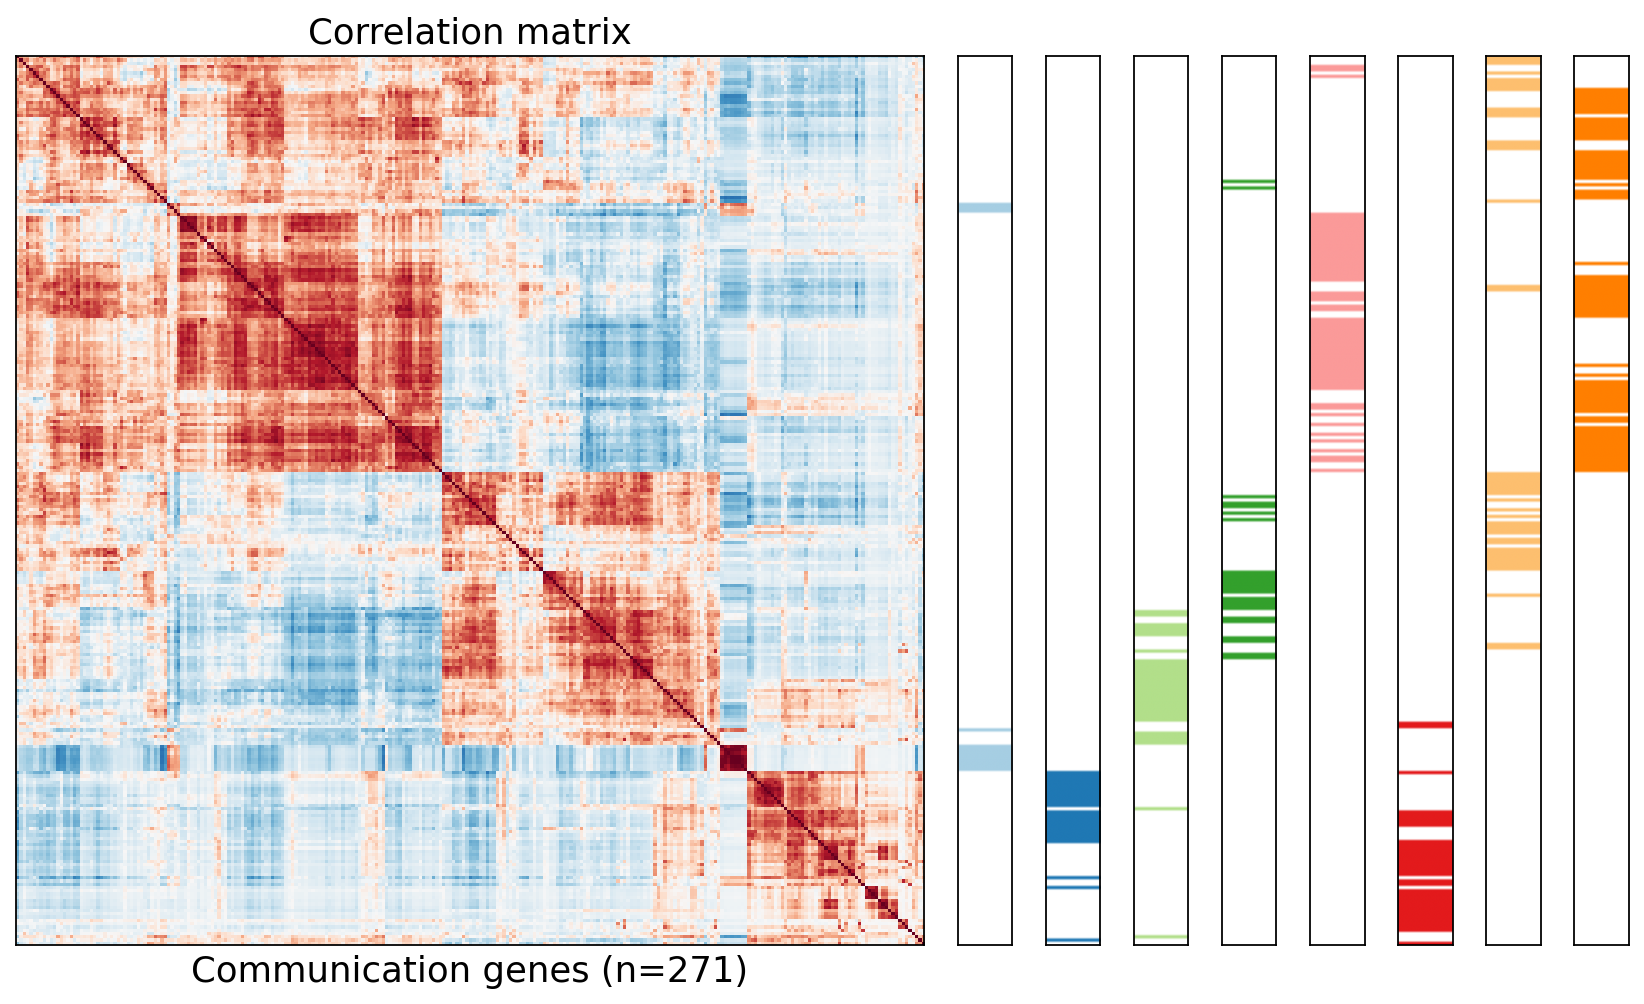

In [ ]:
show_correlation_heatmap(
    corr_matrix = result_epi["corr_mat"], 
    ordering = result_epi["ordering"], 
    cliques = result_epi["cliques_iterative"], 
    use_labels = [], 
    selected_type = 'Epi_dissociated_paracrine_only', 
    save_plot = False
)

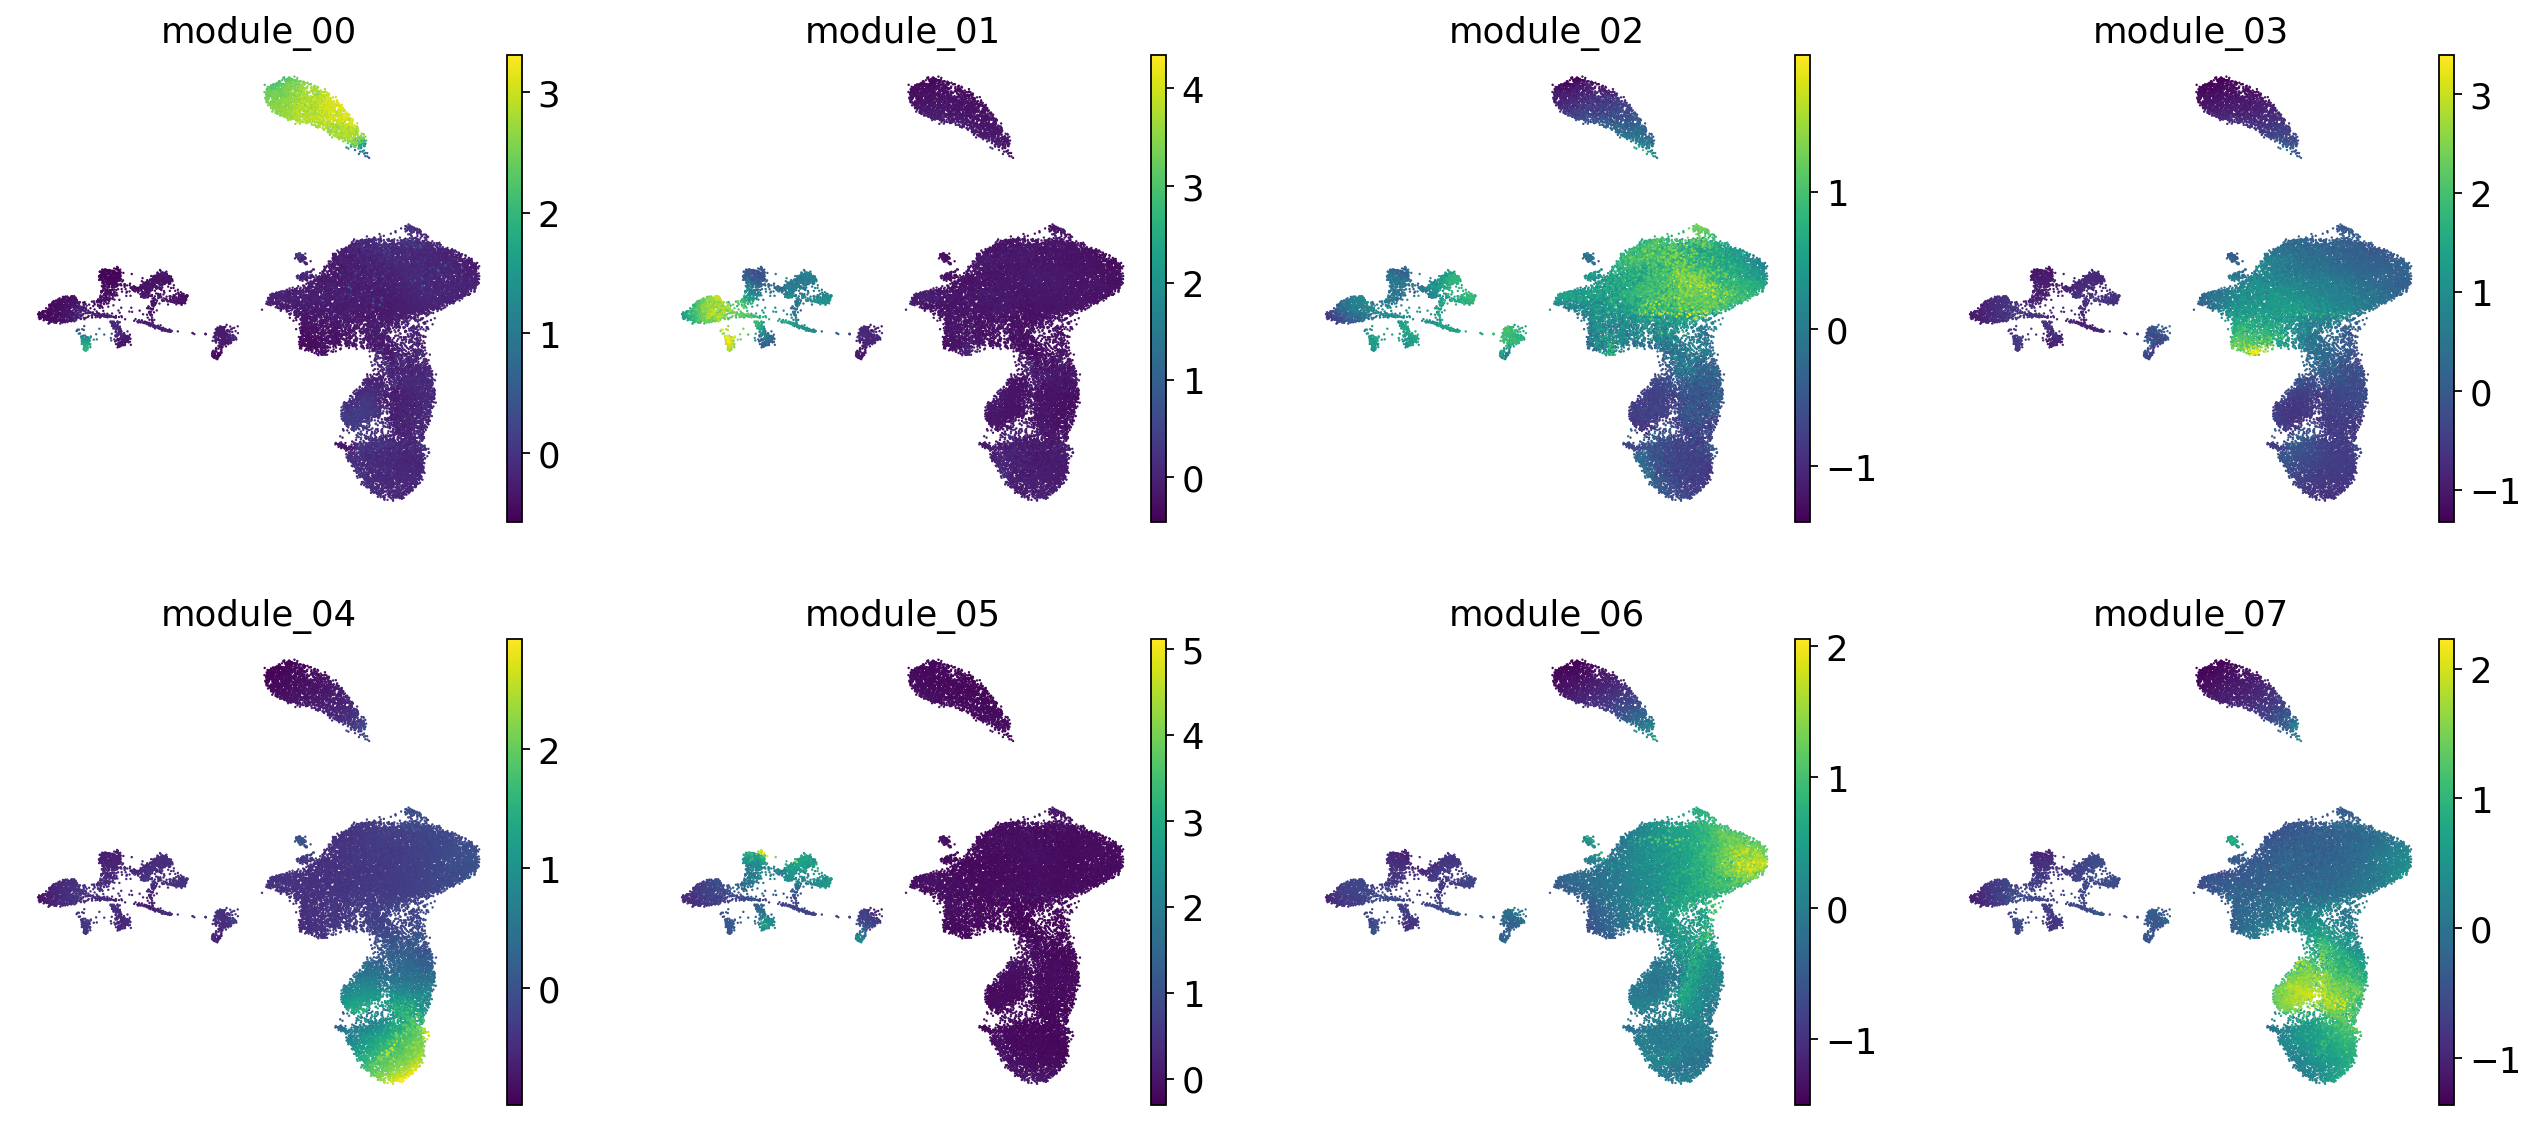

In [ ]:
sc.pl.umap(
    adata_epi, frameon=False,
    color=['module_00', 'module_01', 'module_02', 'module_03', 'module_04', 'module_05', 'module_06', 'module_07'],
)


In [ ]:
module_dictionary = dict()
module_dictionary['epi_0'] = 'adm'
module_dictionary['epi_1'] = 'neuroendocrine_1'
module_dictionary['epi_2'] = 'gastric'
module_dictionary['epi_3'] = 'gastric_pit'
module_dictionary['epi_4'] = 'progenitor2'
module_dictionary['epi_5'] = 'neuroendocrine_2'
module_dictionary['epi_6'] = 'gastric_duct'
module_dictionary['epi_7'] = 'progenitor1'

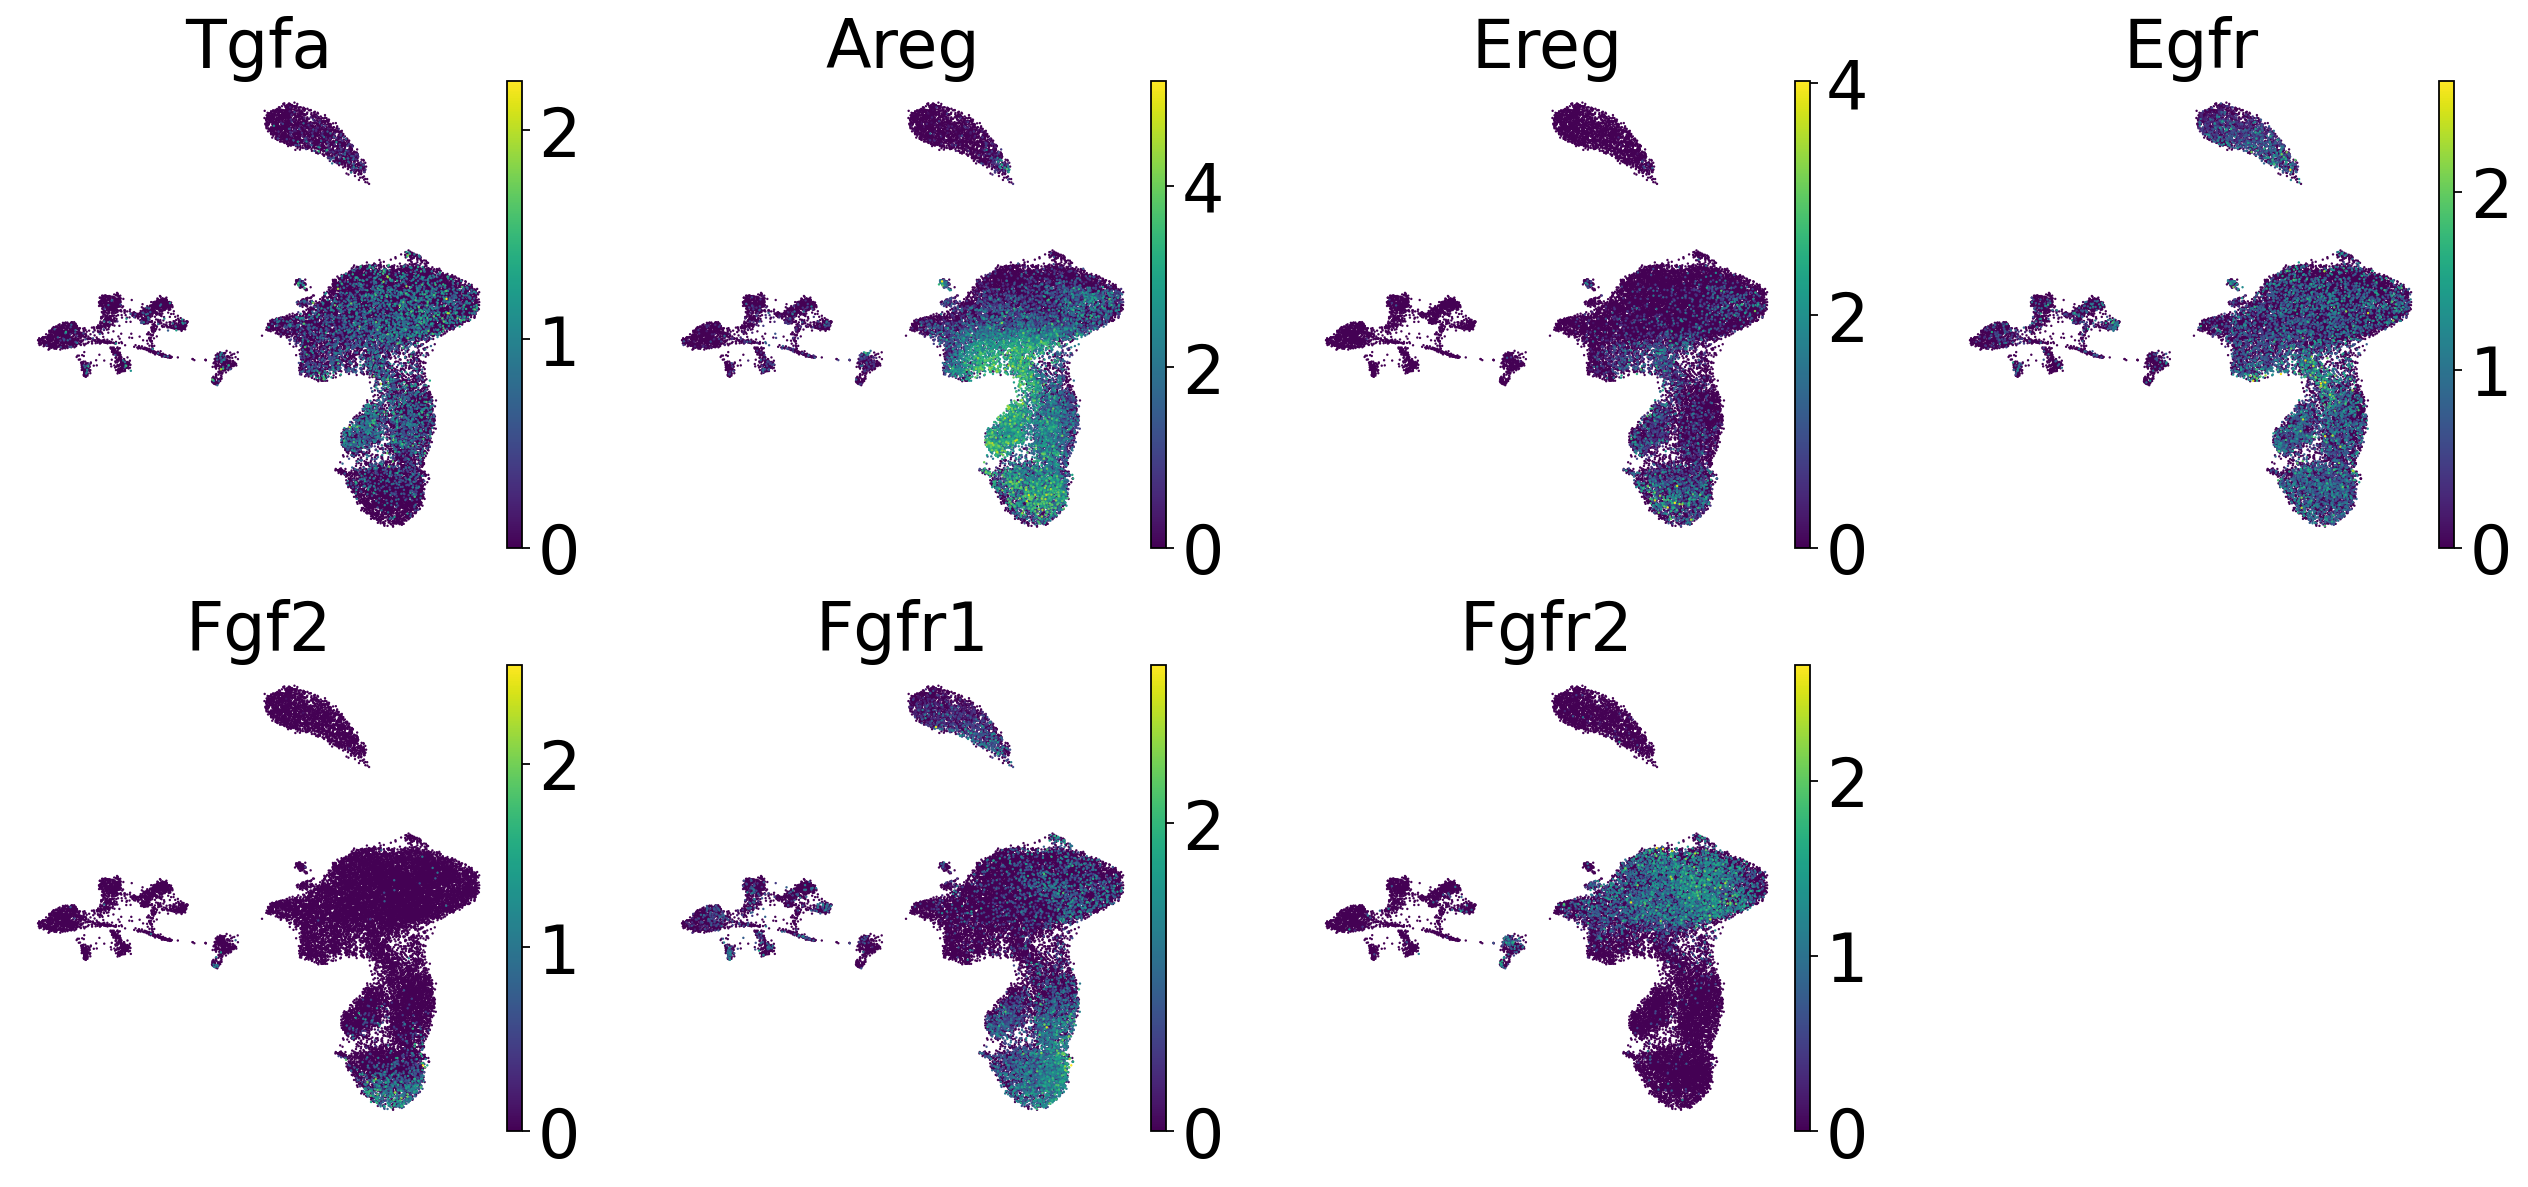

In [ ]:
sc.set_figure_params(scanpy=True, fontsize=30)
adata_temp = adata_epi.copy()
adata_temp.var_names = [x.capitalize() for x in adata_temp.var_names]
sc.pl.umap(
    adata_temp, frameon=False,
    color=['Tgfa', 'Areg', 'Ereg', 'Egfr', 'Fgf2', 'Fgfr1', 'Fgfr2'],
)


### Annotate Myeloid

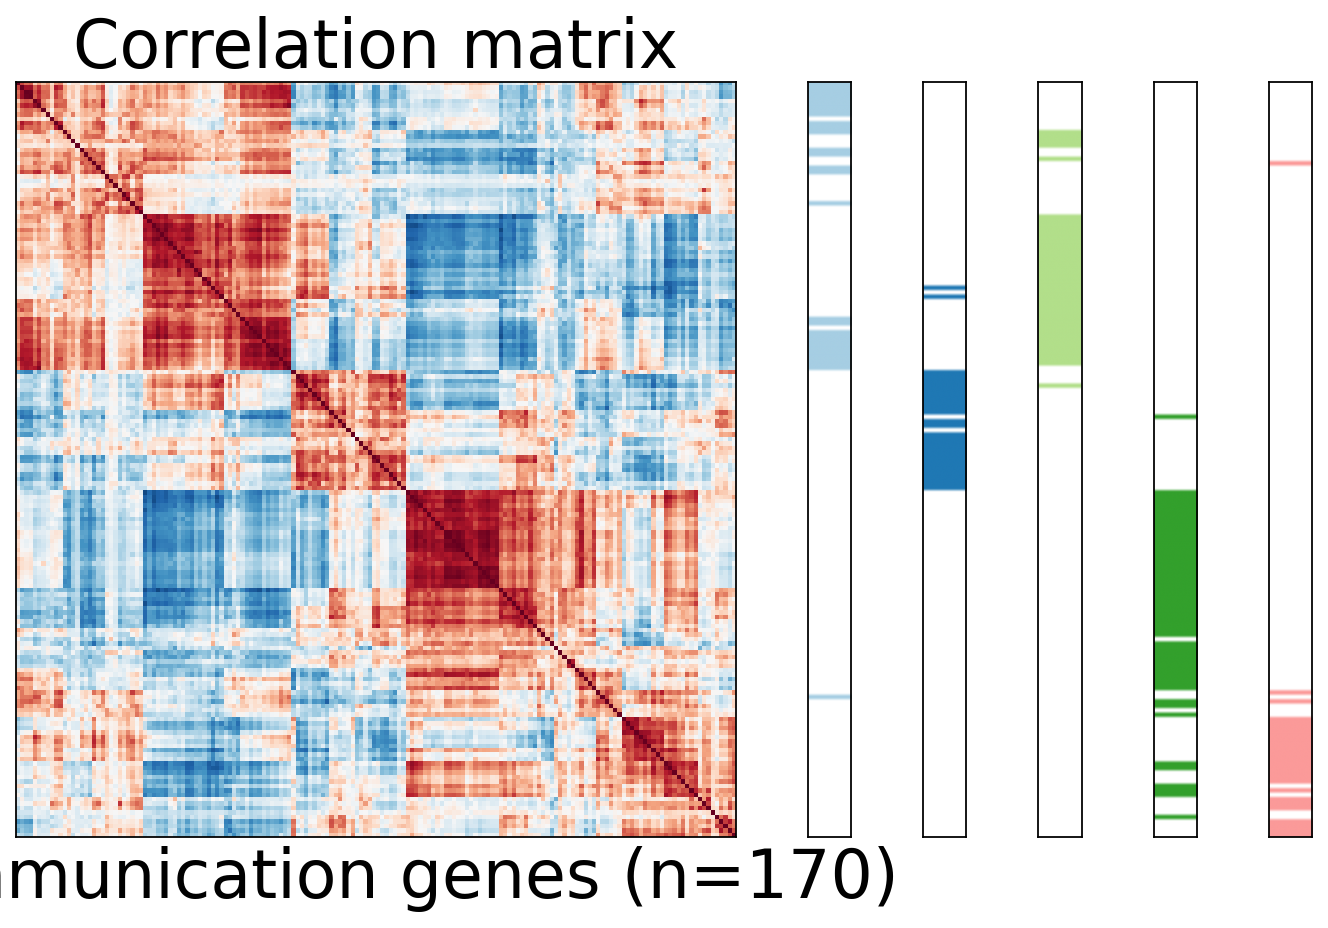

In [ ]:
show_correlation_heatmap(
    corr_matrix = result_TAM["corr_mat"], 
    ordering = result_TAM["ordering"], 
    cliques = result_TAM["cliques_iterative"], 
    use_labels = [], 
    selected_type = 'myeloid_dissociated_paracrine_only', 
    save_plot = False
)

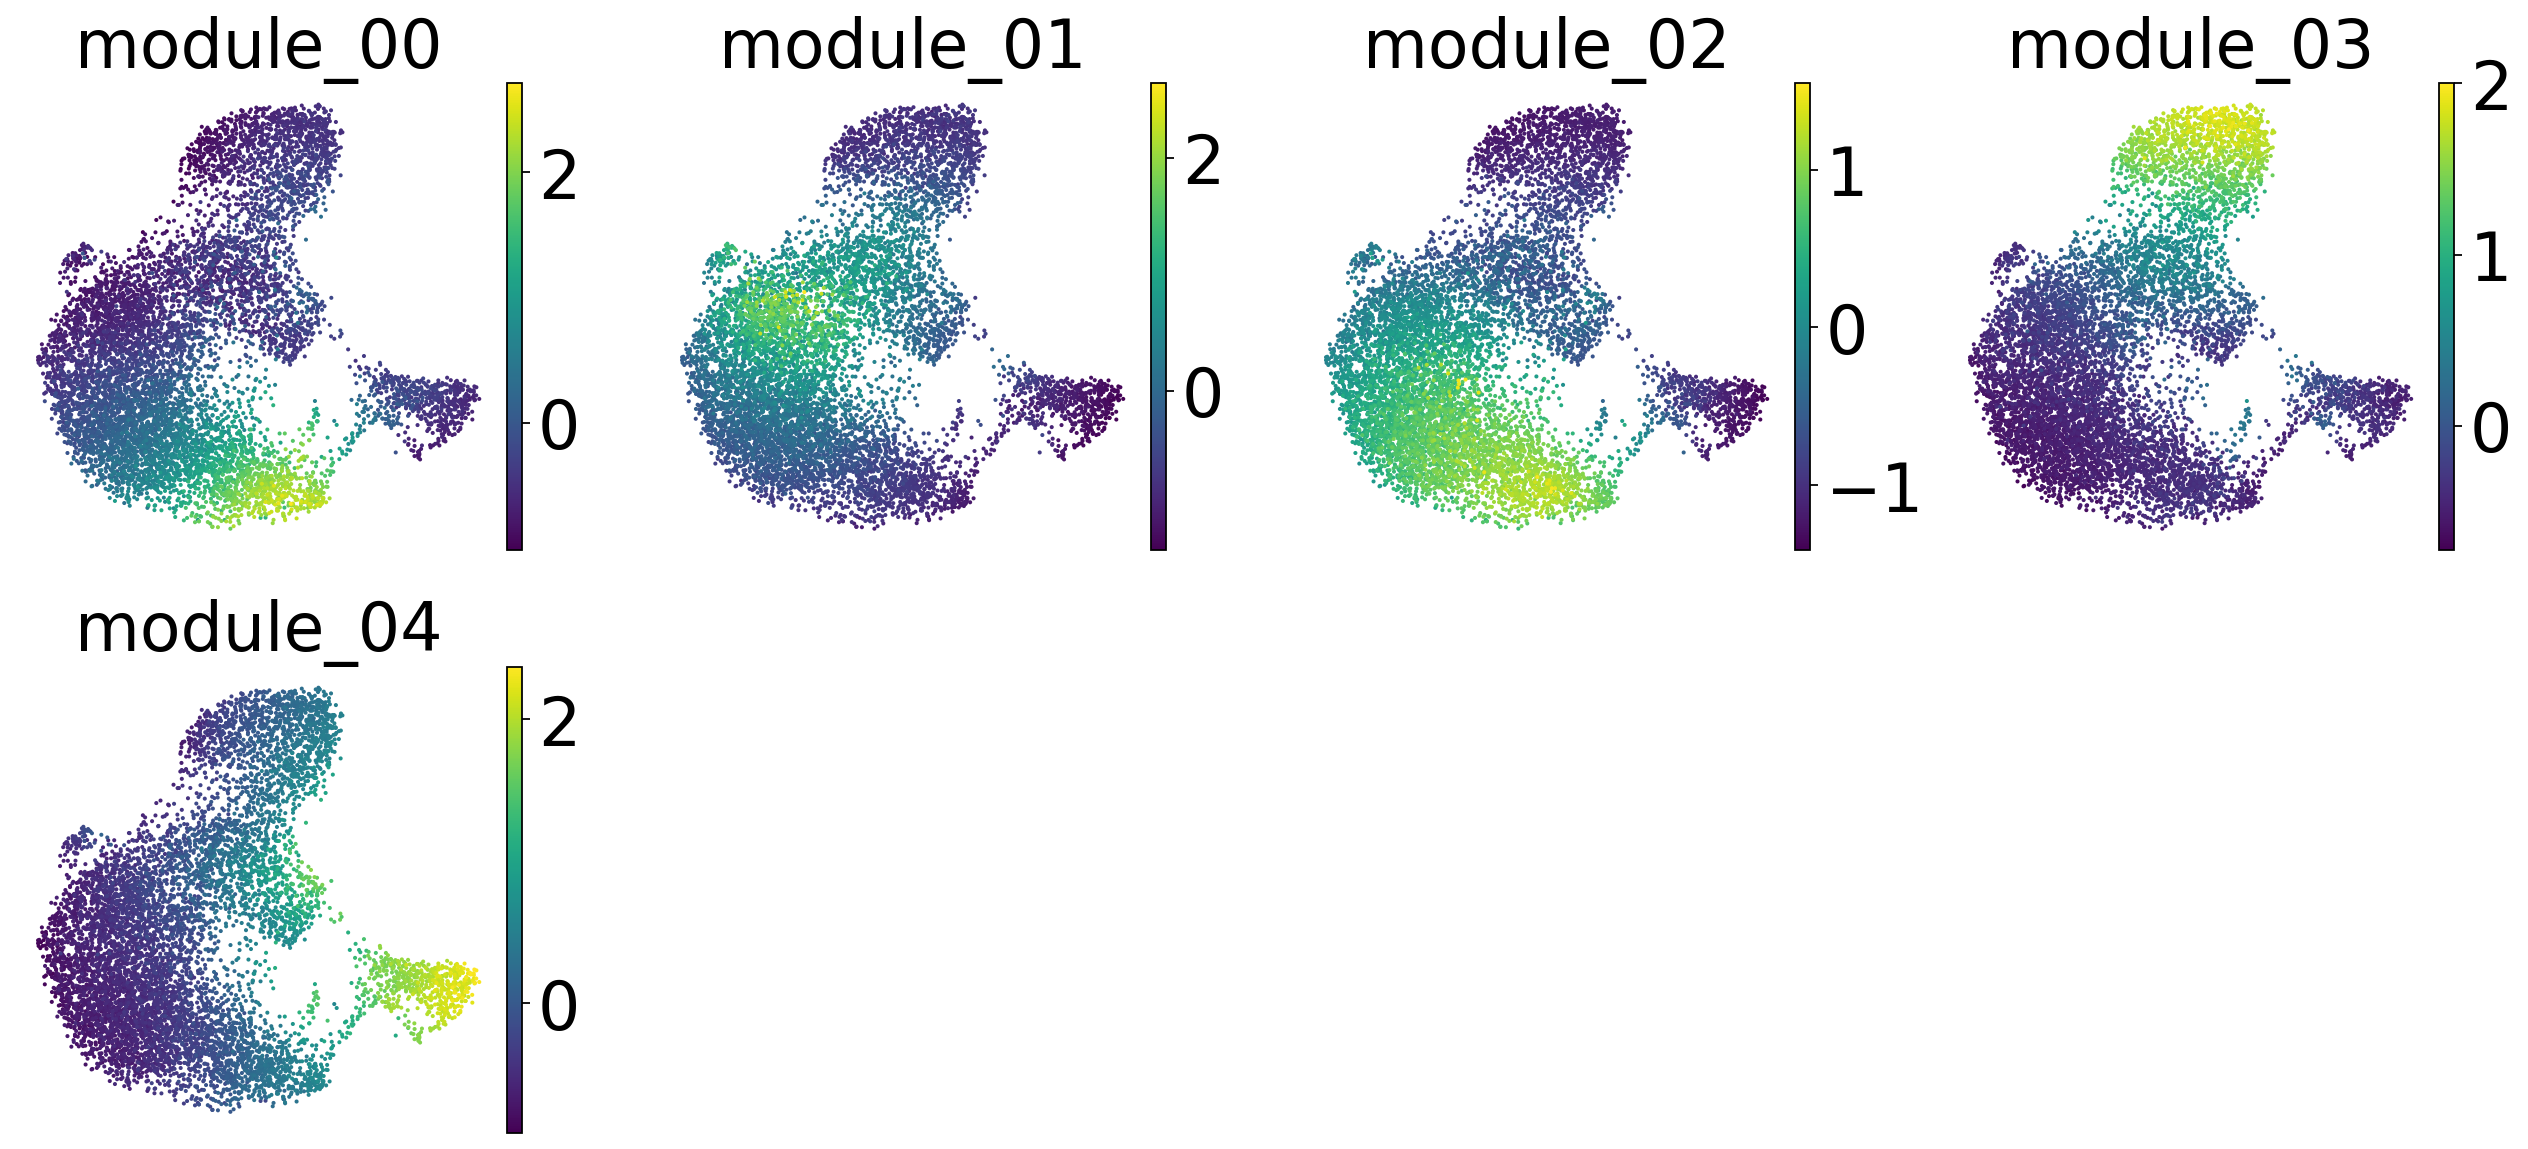

In [ ]:
sc.pl.umap(
    adata_TAM, color=['module_00', 'module_01', 'module_02', 'module_03', 'module_04'], frameon=False,
)

In [ ]:
module_dictionary['myeloid_0'] = 'TAM_Folr2'
module_dictionary['myeloid_1'] = 'TAM_Itgax'
module_dictionary['myeloid_2'] = 'TAM_Maf'
module_dictionary['myeloid_3'] = 'TAM_Cd274'
module_dictionary['myeloid_4'] = 'TAM_Retnla'


### Annotate fibroblasts

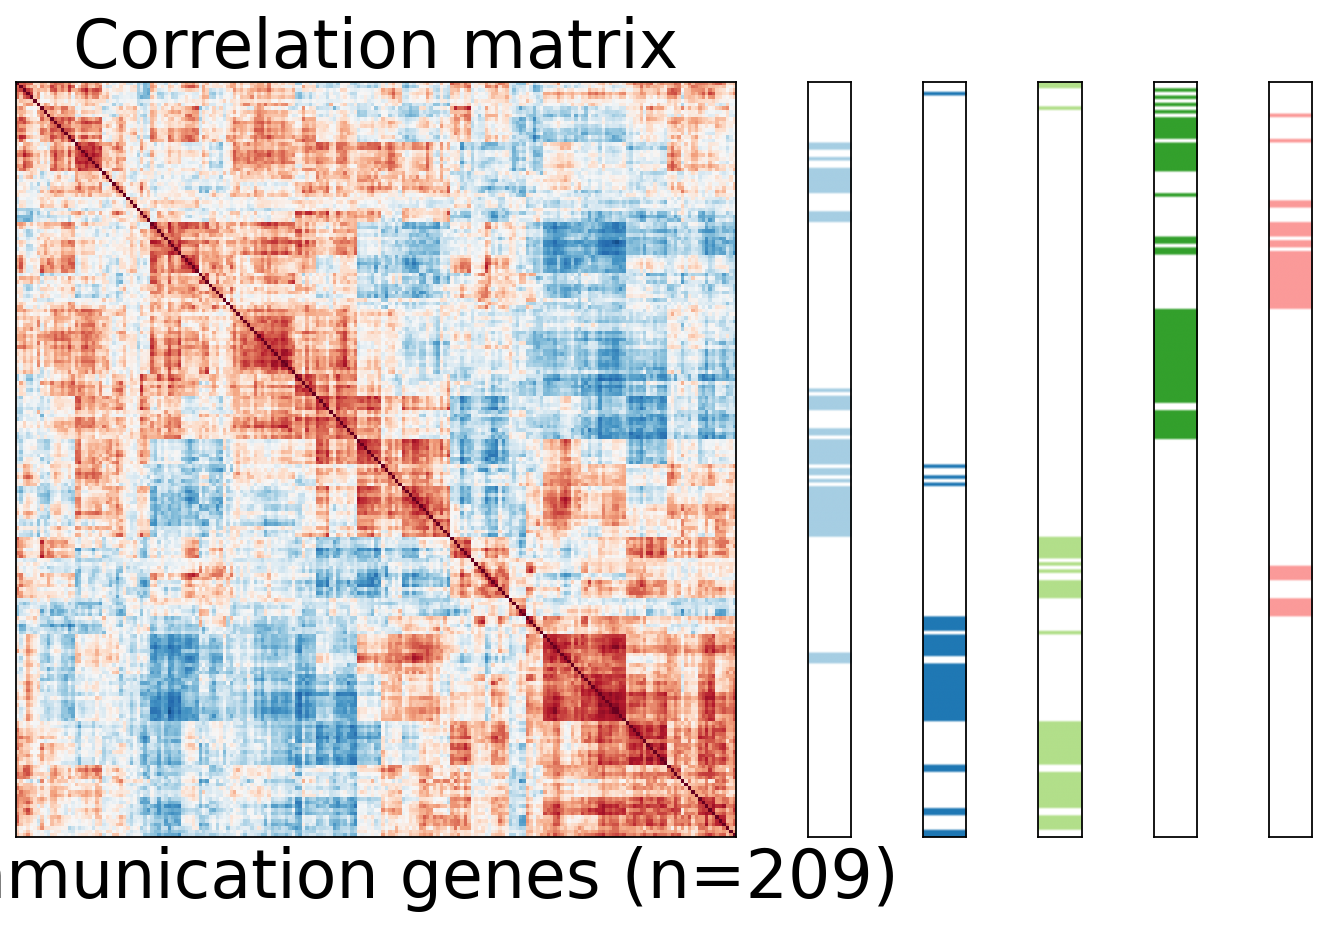

In [ ]:
show_correlation_heatmap(
    corr_matrix = result_fib["corr_mat"], 
    ordering = result_fib["ordering"], 
    cliques = result_fib["cliques_iterative"], 
    use_labels = [], 
    selected_type = 'fib_dissociated_paracrine_only', 
    save_plot = False
)

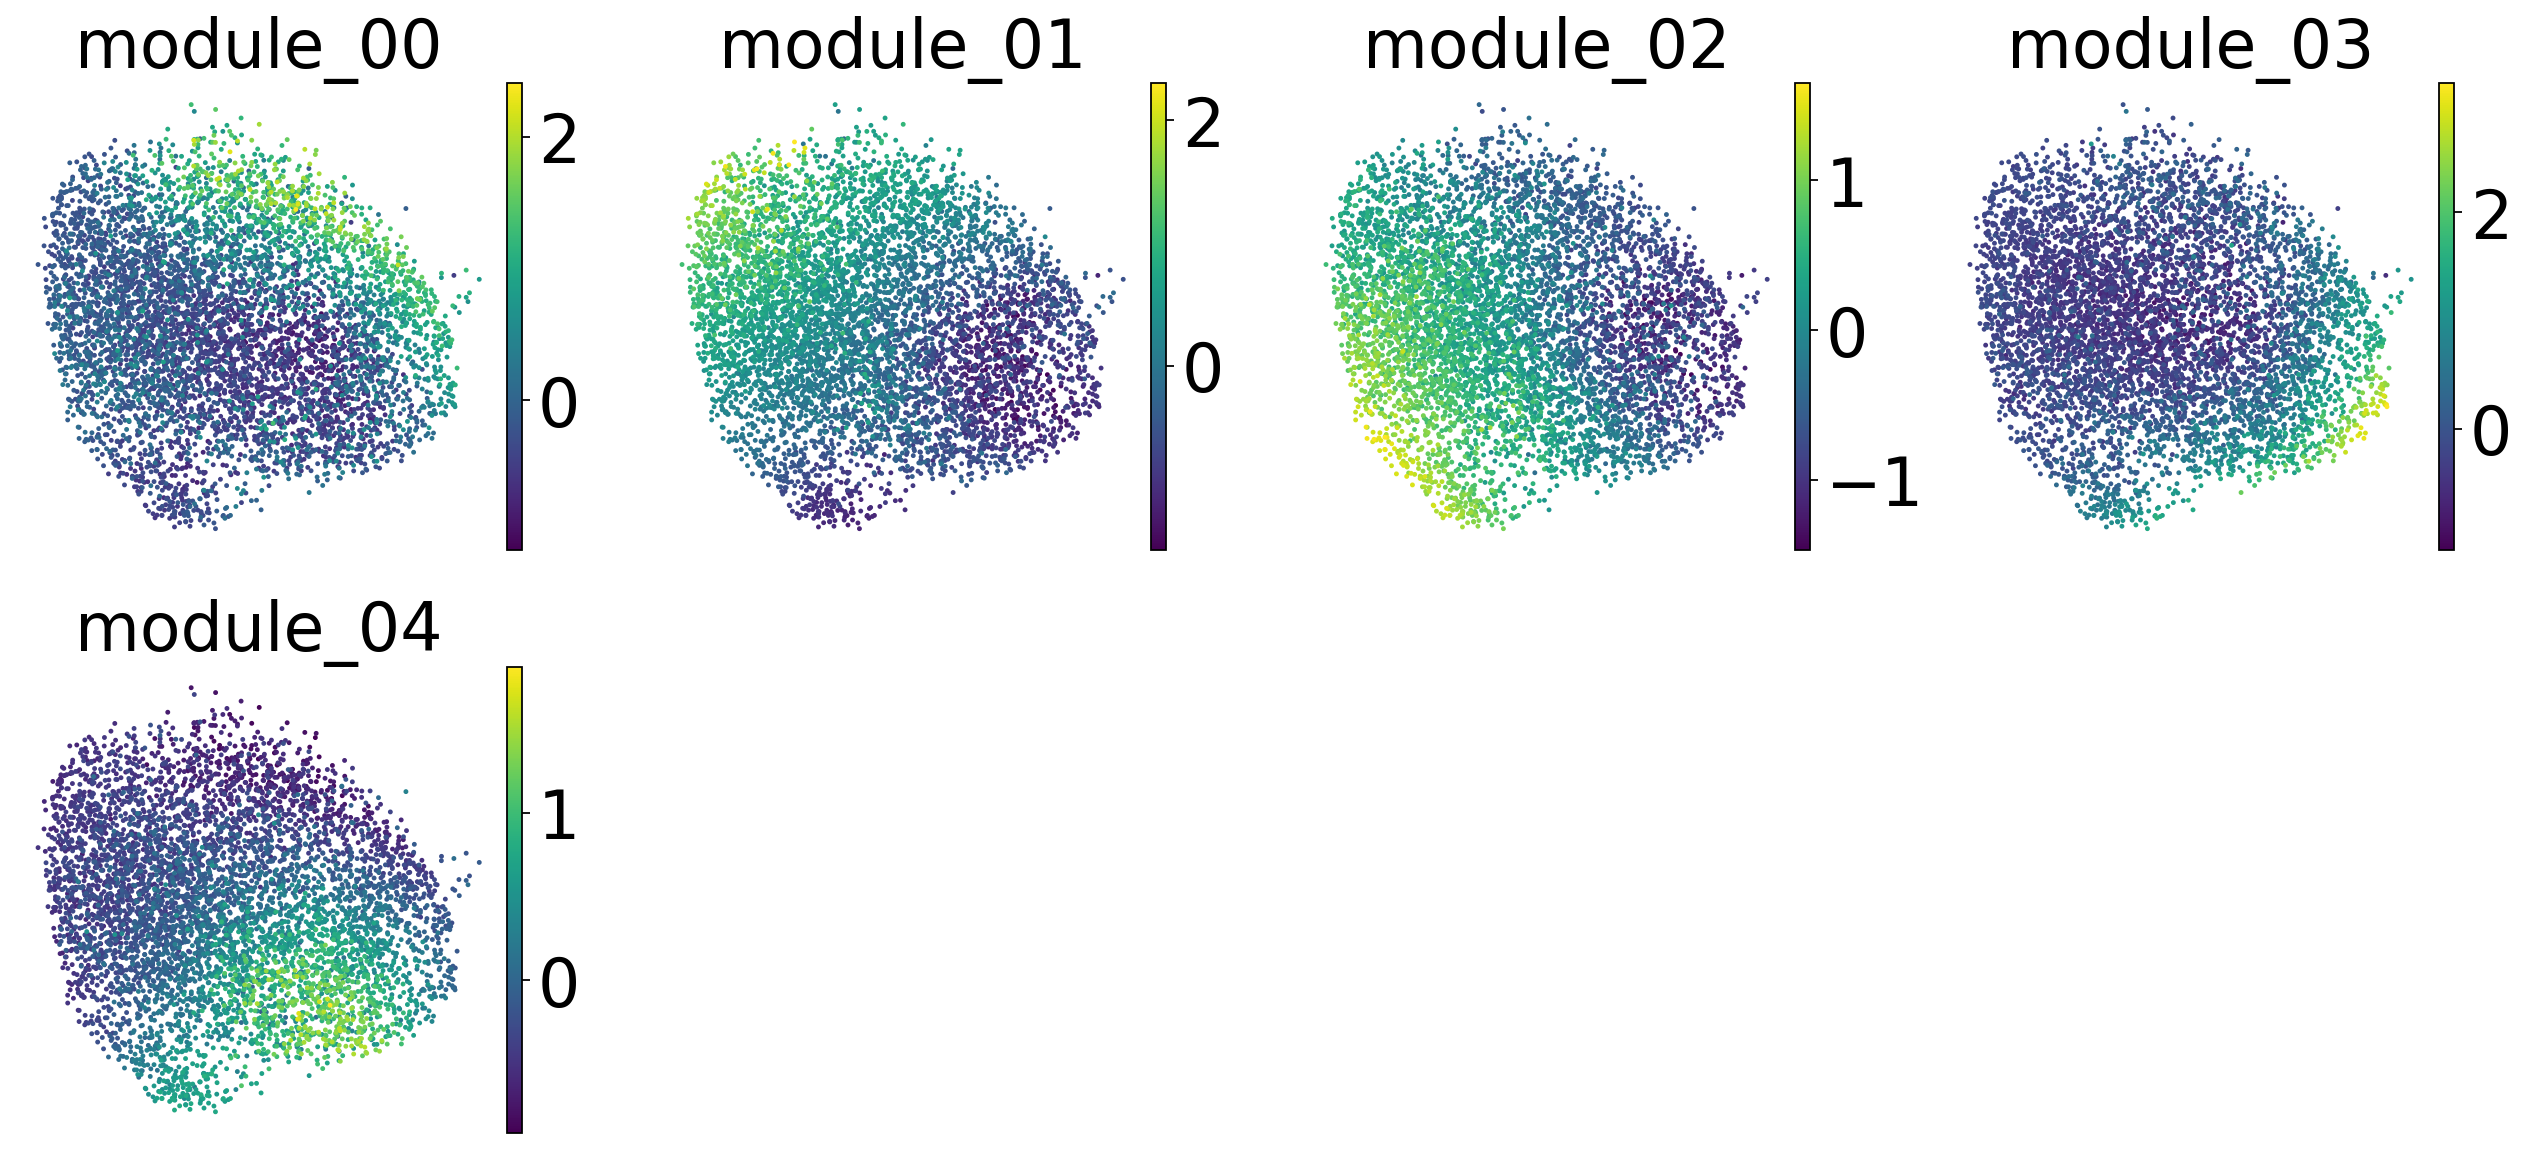

In [ ]:
sc.pl.umap(
    adata_fib, frameon=False, color=['module_00', 'module_01', 'module_02', 'module_03', 'module_04'],
)

In [ ]:
module_dictionary['fib_0'] = 'fib_Ccn2_1'
module_dictionary['fib_1'] = 'fib_Tnxb'
module_dictionary['fib_2'] = 'fib_Igf2'
module_dictionary['fib_3'] = 'fib_Tnc'
module_dictionary['fib_4'] = 'fib_Gli1'


### Prepare clique dictionary

In [ ]:
def get_clique_dictionary(cliques_list, labels):
    clique_dictionary = dict()
    for my_cliques, my_label in zip(cliques_list, labels):
        for i, current_clique in enumerate(my_cliques):
            clique_dictionary[my_label + "_" + str(i)] = current_clique
    return(clique_dictionary)


In [ ]:
cliques_list = [result_epi['cliques_iterative'], result_fib['cliques_iterative'], result_TAM['cliques_iterative']]
clique_labels = ['epi', 'fib', 'myeloid']
clique_dictionary = get_clique_dictionary(cliques_list, clique_labels)

In [ ]:
module_dictionary

{'epi_0': 'adm',
 'epi_1': 'neuroendocrine_1',
 'epi_2': 'gastric',
 'epi_3': 'gastric_pit',
 'epi_4': 'progenitor2',
 'epi_5': 'neuroendocrine_2',
 'epi_6': 'gastric_duct',
 'epi_7': 'progenitor1',
 'myeloid_0': 'TAM_Folr2',
 'myeloid_1': 'TAM_Itgax',
 'myeloid_2': 'TAM_Maf',
 'myeloid_3': 'TAM_Cd274',
 'myeloid_4': 'TAM_Retnla',
 'fib_0': 'fib_Ccn2_1',
 'fib_1': 'fib_Tnxb',
 'fib_2': 'fib_Igf2',
 'fib_3': 'fib_Tnc',
 'fib_4': 'fib_Gli1'}

In [ ]:
module_colors = {
    'adm': "cyan",
    'progenitor1': "red",
    'tuft': "paleturquoise",
    'progenitor2': "orangered",
    'gastric_pit': "mediumblue",
    'neuroendocrine_1': "paleturquoise",
    'neuroendocrine_2': "paleturquoise",
    'neuroendocrine': "paleturquoise",
    'gastric_duct': "mediumblue",
    'gastric': "mediumblue",
    'metaplastic': 'navy',
    'TAM_Maf': 'gold',
    'TAM_Folr2': 'gold',
    'TAM_Itgax_Maf': 'pink',
    'TAM_Plac8': 'lightgray',
    'TAM_Itgax': 'deeppink',
    'TAM_Cd274': 'deeppink',
    'TAM_Retnla': 'lightgray',
    'fib_undefined': 'lightgray',
    'fib_Tnxb': 'limegreen',
    'fib_Igf2': 'greenyellow',
    'fib_Ccn2_2': 'mediumorchid',
    'fib_Ccn2_1': 'mediumorchid',
    'fib_Gli1': 'limegreen',
    'fib_Tnc': 'indigo'
}
clique_colors = {x: module_colors[module_dictionary[x]] for x in clique_dictionary.keys()}
clique_colors

{'epi_0': 'cyan',
 'epi_1': 'paleturquoise',
 'epi_2': 'mediumblue',
 'epi_3': 'mediumblue',
 'epi_4': 'orangered',
 'epi_5': 'paleturquoise',
 'epi_6': 'mediumblue',
 'epi_7': 'red',
 'fib_0': 'mediumorchid',
 'fib_1': 'limegreen',
 'fib_2': 'greenyellow',
 'fib_3': 'indigo',
 'fib_4': 'limegreen',
 'myeloid_0': 'gold',
 'myeloid_1': 'deeppink',
 'myeloid_2': 'gold',
 'myeloid_3': 'deeppink',
 'myeloid_4': 'lightgray'}

### Import calligraphy results

In [ ]:
suffix_dataset = 'dissociatedEpi'
suffix_figures = suffix_dataset + "_paracrine_only"

In [ ]:
result_calligraphy = read_object(os.path.join(output_dir, "result_calligraphy_imputed_T2_" + suffix_dataset + ".pydata"))
result_calligraphy_df = result_calligraphy['calligraphy_result']
df = pd.DataFrame([re.findall("(\w+_\d)__(\w+_\d)", x)[0] for x in result_calligraphy_df.index.to_numpy()], columns = ['sender', 'receiver'], index = result_calligraphy_df.index)
result_calligraphy_df = pd.concat([result_calligraphy_df, df], axis = 1)
result_calligraphy_df['sender_nickname'] = [module_dictionary[x] for x in result_calligraphy_df['sender']]
result_calligraphy_df['receiver_nickname'] = [module_dictionary[x] for x in result_calligraphy_df['receiver']]

### General plotting strategy

In [ ]:
def format_publication_graph(G, nodelist = None, edge_scale = 0.1,connectionstyle="arc3,rad=0.2", layout_type = 'circular'):
    layer_dictionary = {'epi': 1, 'fib': 0, 'myeloid': 2}
    for my_node in G.nodes:
        current_key = re.sub("_\d+", "", my_node)
        G.nodes[my_node]['layer'] = layer_dictionary[current_key]
    if nodelist is None:
        nodelist = list(G.nodes)
    node_colors_dict = {"epi":"turquoise","fib":"deeppink",'myeloid':"gold"}
    node_colors = [node_colors_dict[node.split("_")[0]] for node in nodelist]
    #node_colors = [clique_colors[node] for node in nodelist]
    node_sizes = [len(clique_dictionary[x]) for x in nodelist]
    if layout_type == 'multipartite':
        pos = nx.multipartite_layout(G, subset_key='layer')
    else:
        pos = nx.circular_layout(G)
    
    labels_dictionary = {x:module_dictionary[x] for x in nodelist}
    
    fig,ax=plt.subplots(figsize=(2,2))
    pos_epi = plot_graph(
        G,
        node_sizes=node_sizes,
        nodelist=nodelist,
        labels=labels_dictionary,
        color_edges=True,
        node_scale=1,
        edge_scale=edge_scale,
        color_nodes=node_colors,
        pos = pos,
        connectionstyle = connectionstyle
    )

### Plot original graph

In [ ]:
significant_df = result_calligraphy_df.copy()
scores = significant_df["p-value"]
scores.index = [re.sub("__", "_", x) for x in scores.index]
scores = -np.log(scores + 0.0001) / np.log(10)

G, _ = generate_graph_scores(result_calligraphy['G'],scores)
nodelist = list(np.unique(significant_df['sender'].to_list() + significant_df['receiver'].to_list()))


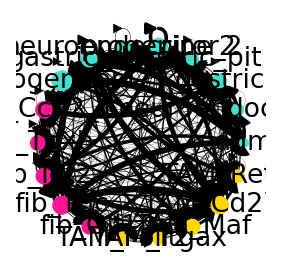

In [ ]:
format_publication_graph(G, nodelist = nodelist, edge_scale=1)


### Plot significant graph

In [ ]:
significant_df = result_calligraphy_df.loc[result_calligraphy_df['p-value'] < 0.05,:].copy()
scores = significant_df["p-value"]
scores.index = [re.sub("__", "_", x) for x in scores.index]
scores = -np.log(scores + 0.0001) / np.log(10) * 2

In [ ]:
G, _ = generate_graph_scores(result_calligraphy['G'],scores)
nodelist = list(np.unique(significant_df['sender'].to_list() + significant_df['receiver'].to_list()))

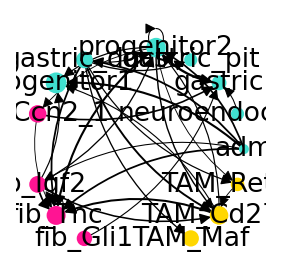

In [ ]:
format_publication_graph(G, nodelist = nodelist, edge_scale = 0.15)

### Explore specific communication modules

In [ ]:
H = nx.relabel_nodes(G, module_dictionary)

In [ ]:
H['TAM_Cd274']['progenitor2']

{'width': 3.5545670577048334,
 'color': '#b5b5b5',
 'genes_pairs': ['ANGPTL4_ITGA5',
  'ANGPTL4_ITGB1',
  'ANGPTL4_ITGB3',
  'ANGPTL4_SDC2',
  'MIF_ACKR3',
  'MIF_CD44',
  'MIF_CXCR4',
  'OSM_OSMR',
  'PROS1_AXL',
  'SPP1_CD44',
  'SPP1_ITGA5',
  'SPP1_ITGB1',
  'SPP1_ITGB3',
  'SPP1_ITGB5',
  'TGFB1_ACVR1',
  'TGFB1_TGFBR2']}

In [ ]:
H['progenitor2']['TAM_Cd274']

{'width': 4.2498774732166,
 'color': '#b5b5b5',
 'genes_pairs': ['ANGPTL2_ITGA5',
  'ANGPTL2_TLR4',
  'ANGPTL4_ITGA5',
  'ANXA1_FPR1',
  'ANXA1_FPR2',
  'BMP2_BMPR2',
  'CCL7_CCR1',
  'CSF2_CSF2RA',
  'CSF2_CSF2RB',
  'IL11_IL6ST',
  'INHBA_ACVR1B',
  'INHBB_ACVR1B',
  'PROS1_AXL',
  'TGFB1_ACVR1B',
  'TGFB2_ACVR1B',
  'TGFB3_ACVR1B',
  'TNFSF12_TNFRSF12A',
  'WNT11_FZD1',
  'WNT11_FZD4',
  'WNT11_FZD7',
  'WNT9A_FZD1',
  'WNT9A_FZD4',
  'WNT9A_FZD7']}